start Node: (31, 40)
goal Node: (15, 10)


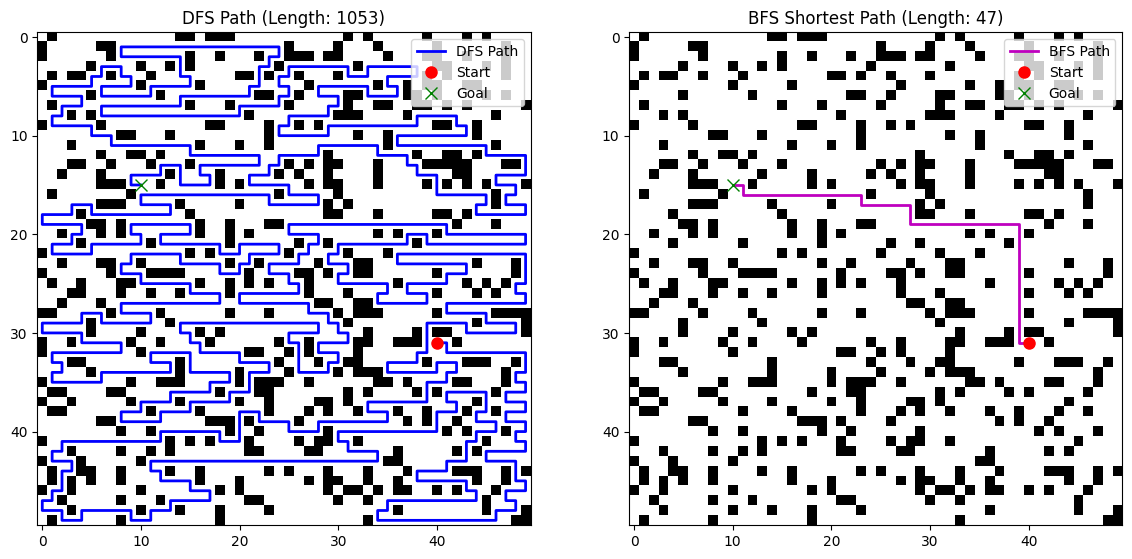

In [ ]:
#q1- DBA and BFS
import numpy as np
import matplotlib.pyplot as plt
from collections import deque
import random
#1] Setup Grid and Environment
grid_size = 50
grid = np.zeros((grid_size, grid_size))
#Add random obstacles (20% density)
obstacles = np.random.rand(grid_size, grid_size) < 0.20
grid[obstacles] = 1
#Assign start and goal randomly
def get_random_free_node():
    while True:
        y, x = random.randint(0, grid_size - 1), random.randint(0, grid_size - 1)
        if grid[y, x] == 0:
            return (y, x)

start = get_random_free_node()
goal = get_random_free_node()
while start == goal:
    goal = get_random_free_node()

print(f"start Node: {start}")
print(f"goal Node: {goal}")

#2]Depth First Search (DFS)
def dfs(grid, start, goal):
    stack = [start]
    visited = set()
    came_from = {}

    while stack:
        current = stack.pop() # LIFO behavior makes it DFS

        if current == goal:
            break

        if current not in visited:
            visited.add(current)

            for dy, dx in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
                ny, nx = current[0] + dy, current[1] + dx

                if 0 <= ny < grid_size and 0 <= nx < grid_size:
                    if grid[ny, nx] == 0 and (ny, nx) not in visited:
                        came_from[(ny, nx)] = current
                        stack.append((ny, nx))

    #Reconstruct path
    path = []
    curr = goal
    if curr in came_from or curr == start:
        while curr != start:
            path.append(curr)
            curr = came_from.get(curr)
            if curr is None: return [] # No path found
        path.append(start)
        path.reverse()
    return path

#3]Breadth First Search (BFS - Modified for Shortest Path
def bfs_shortest_path(grid, start, goal):
    queue = deque([start])
    visited = set([start])
    came_from = {}

    while queue:
        current = queue.popleft() # FIFO behavior makes it BFS

        if current == goal:
            break

        for dy, dx in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
            ny, nx = current[0] + dy, current[1] + dx

            if 0 <= ny < grid_size and 0 <= nx < grid_size:
                if grid[ny, nx] == 0 and (ny, nx) not in visited:
                    visited.add((ny, nx))
                    came_from[(ny, nx)] = current
                    queue.append((ny, nx))

    #Reconstruc path
    path = []
    curr = goal
    if curr in came_from or curr == start:
        while curr != start:
            path.append(curr)
            curr = came_from.get(curr)
            if curr is None: return [] #when No path is found
        path.append(start)
        path.reverse()
    return path

#4]execute, Plot
path_dfs = dfs(grid, start, goal)
path_bfs = bfs_shortest_path(grid, start, goal)
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

#plot DFS
axes[0].imshow(grid, cmap='gray_r')
axes[0].set_title(f"DFS ppath (length: {len(path_dfs)})")
if path_dfs:
    dfs_y, dfs_x = zip(*path_dfs)
    axes[0].plot(dfs_x, dfs_y, 'b-', linewidth=2, label='DFS Path')
axes[0].plot(start[1], start[0], 'ro', markersize=8, label='Start')
axes[0].plot(goal[1], goal[0], 'gx', markersize=8, label='Goal')
axes[0].legend()
#plot BFS
axes[1].imshow(grid, cmap='gray_r')
axes[1].set_title(f"BFS shortest path (Length: {len(path_bfs)})")
if path_bfs:
    bfs_y, bfs_x = zip(*path_bfs)
    axes[1].plot(bfs_x, bfs_y, 'm-', linewidth=2, label='BFS Path')
axes[1].plot(start[1], start[0], 'ro', markersize=8, label='Start')
axes[1].plot(goal[1], goal[0], 'gx', markersize=8, label='Goal')
axes[1].legend()
plt.show()

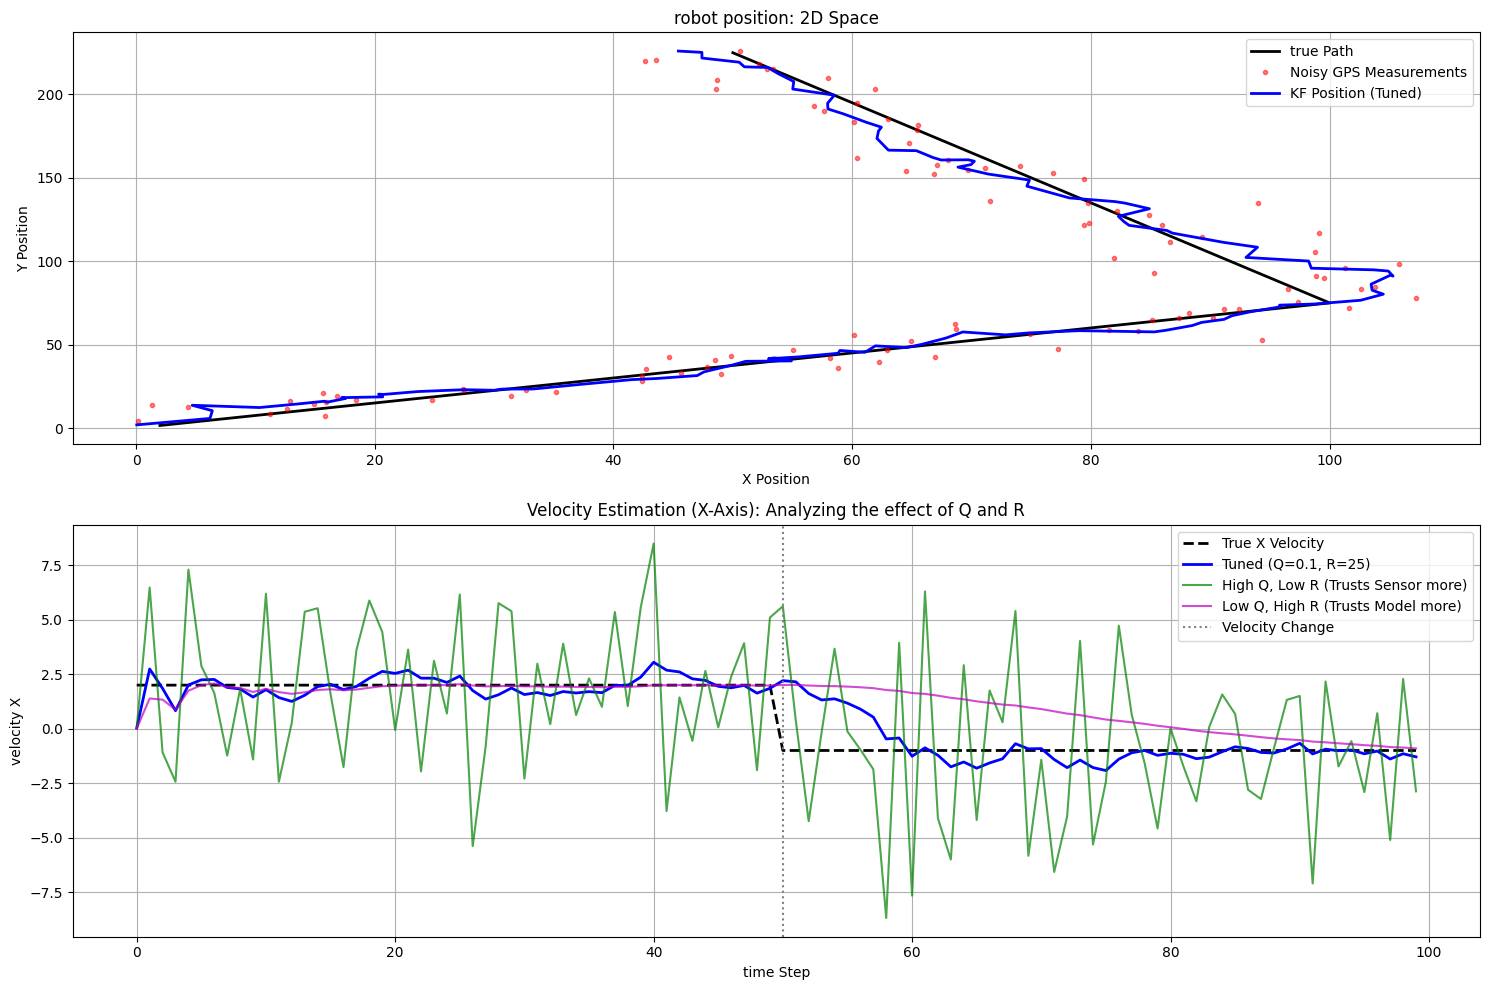

In [ ]:
#q2- kalman filter fo r velocity prediction. assumed input as gps coordinates of the robot.
import numpy as np
import matplotlib.pyplot as plt
#setup and data Simulation
dt = 1.0
num_steps = 100

#True state variables
true_pos_x, true_pos_y = 0.0, 0.0
true_vel_x, true_vel_y = 2.0, 1.5

true_states = []
measurements = []

#generatin ground truth and noisy GPS measurements
gps_noise_std = 5.0

for i in range(num_steps):
    #introduce a sudden velocity change at some point. here when i=num_steps//2
    if i == num_steps // 2:
        true_vel_x = -1.0
        true_vel_y = 3.0

    #update true position
    true_pos_x += true_vel_x * dt
    true_pos_y += true_vel_y * dt

    true_states.append([true_pos_x, true_pos_y, true_vel_x, true_vel_y])

    #simulate GPS reading by adding Gaussian noise to true position
    z_x = true_pos_x + np.random.normal(0, gps_noise_std)
    z_y = true_pos_y + np.random.normal(0, gps_noise_std)
    measurements.append([z_x, z_y])

true_states = np.array(true_states)
measurements = np.array(measurements)
#main Kalman Filter Implementation
def run_kalman_filter(measurements, Q_scale, R_scale):
    # System dimensions
    state_dim = 4
    meas_dim = 2

    # State transition matrix (A)
    A = np.array([[1, 0, dt, 0],
                  [0, 1, 0, dt],
                  [0, 0, 1, 0],
                  [0, 0, 0, 1]])

    # Observation matrix (H)
    H = np.array([[1, 0, 0, 0],
                  [0, 1, 0, 0]])

    # Process noise covariance (Q)
    # Represents uncertainty in the model (e.g., unexpected accelerations)
    Q = np.eye(state_dim) * Q_scale

    # Measurement noise covariance (R)
    # Represents uncertainty in the GPS sensor
    R = np.eye(meas_dim) * R_scale

    # Initial state estimate (x_hat) and covariance (P)
    x_hat = np.array([0, 0, 0, 0]).reshape(-1, 1)
    P = np.eye(state_dim) * 10.0

    estimated_states = []

    for z in measurements:
        z = z.reshape(-1, 1)


        # 1. Project the state ahead
        x_hat_minus = A @ x_hat
        # 2. Project the error covariance ahead
        P_minus = A @ P @ A.T + Q
        # 3. Compute the Kalman Gain (K)
        S = H @ P_minus @ H.T + R
        K = P_minus @ H.T @ np.linalg.inv(S)
        # 4. Update estimate with measurement z
        y = z - (H @ x_hat_minus) # Measurement residual
        x_hat = x_hat_minus + (K @ y)
        # 5. Update the error covariance
        I = np.eye(state_dim)
        P = (I - K @ H) @ P_minus

        estimated_states.append(x_hat.flatten())

    return np.array(estimated_states)


#Analyze Q and R effects
#Case A: Balanced/Tuned Filter
est_tuned = run_kalman_filter(measurements, Q_scale=0.1, R_scale=gps_noise_std**2)

#Case B: High Q, Low R (Trusts sensor heavily, expects highly erratic movement)
est_high_q = run_kalman_filter(measurements, Q_scale=10.0, R_scale=1.0)

#Case C: Low Q, High R (Trusts model heavily, ignores sensor noise, assumes strict constant velocity)
est_high_r = run_kalman_filter(measurements, Q_scale=0.001, R_scale=100.0)
plt.figure(figsize=(15, 10))
#plot 1: 2D Position Map
plt.subplot(2, 1, 1)
plt.plot(true_states[:, 0], true_states[:, 1], 'k-', linewidth=2, label='true Path')
plt.plot(measurements[:, 0], measurements[:, 1], 'r.', alpha=0.5, label='Noisy GPS Measurements')
plt.plot(est_tuned[:, 0], est_tuned[:, 1], 'b-', linewidth=2, label='KF Position (Tuned)')
plt.title('robot position: 2D Space')
plt.xlabel('X Position')
plt.ylabel('Y Position')
plt.legend()
plt.grid(True)
#plot 2: velocity Estimation (X-axis) showing Q/R effects
plt.subplot(2, 1, 2)
time_steps = np.arange(num_steps)
plt.plot(time_steps, true_states[:, 2], 'k--', linewidth=2, label='True X Velocity')
plt.plot(time_steps, est_tuned[:, 2], 'b-', linewidth=2, label='Tuned (Q=0.1, R=25)')
plt.plot(time_steps, est_high_q[:, 2], 'g-', alpha=0.7, label='High Q, Low R (Trusts Sensor more)')
plt.plot(time_steps, est_high_r[:, 2], 'm-', alpha=0.7, label='Low Q, High R (Trusts Model more)')
plt.axvline(x=50, color='gray', linestyle=':', label='Velocity Change')
plt.title('Velocity Estimation (X-Axis): Analyzing the effect of Q and R')
plt.xlabel('time Step')
plt.ylabel('velocity X')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

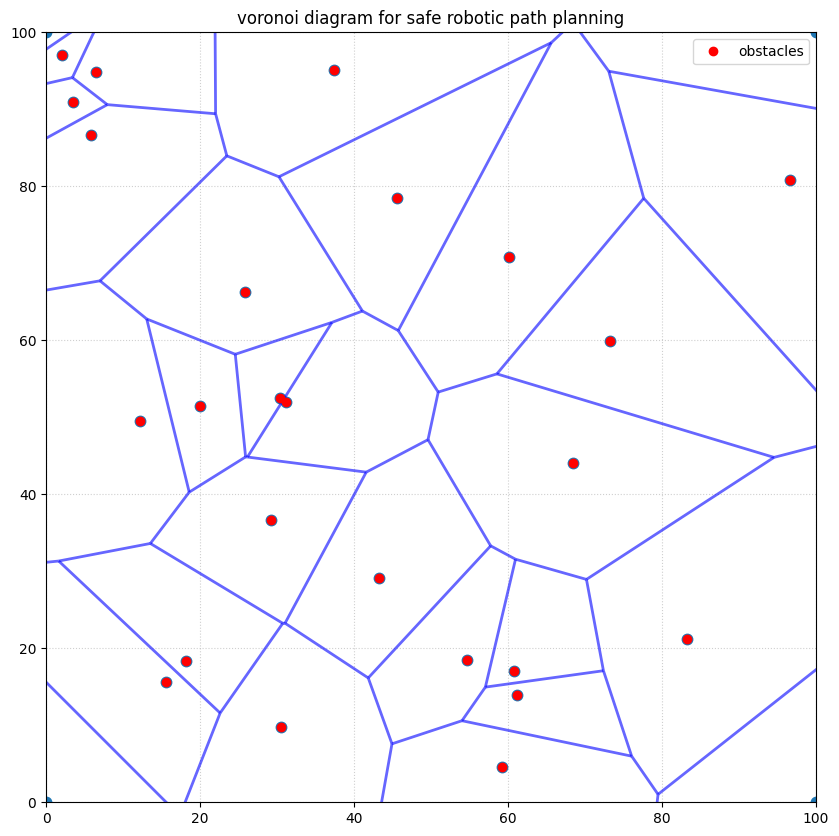

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import Voronoi, voronoi_plot_2d

# define the boundaries of our robot's environment
width = 100
height = 100

# generate random obstacle positions within the environment
num_obstacles = 25
np.random.seed(42) # set seed for reproducible results
obstacles = np.random.rand(num_obstacles, 2) * [width, height]

# add corner points to ensure the voronoi diagram extends to the edges
corners = np.array([[0, 0], [0, height], [width, 0], [width, height]])
points = np.vstack((obstacles, corners))

# compute the voronoi diagram based on obstacle locations
vor = Voronoi(points)

# create the plot
fig, ax = plt.subplots(figsize=(10, 10))

# plot the voronoi diagram
# orange dots represent the obstacles
# blue lines represent the voronoi edges (the safest paths for the robot)
voronoi_plot_2d(vor, ax=ax, show_vertices=False, line_colors='blue',
                line_width=2, line_alpha=0.6, point_size=15)

# highlight the obstacles explicitly for clarity
ax.plot(obstacles[:, 0], obstacles[:, 1], 'ro', markersize=6, label='obstacles')

# format the map
ax.set_xlim(0, width)
ax.set_ylim(0, height)
ax.set_title('voronoi diagram for safe robotic path planning')
ax.set_aspect('equal')
ax.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()